# Country Clustering Analysis

## Objective

The objective of this analysis is to segment countries into groups based on their economic and agricultural characteristics.

Clustering will help identify countries with similar economic stress profiles, income levels, labor market conditions, and food security characteristics.

### Business Question

Which clusters of countries share similar economic and agricultural profiles?

### Analytical Approach

- Data Preparation
- Missing Value Treatment
- Feature Scaling
- Optimal Cluster Identification
- K-Means Clustering
- Cluster Profiling
- Business Interpretation

In [11]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)

import warnings

warnings.filterwarnings('ignore')

In [2]:
# =====================================================
# LOAD DATASET
# =====================================================

country_year = pd.read_csv(
    "C:/Users/saksh/Desktop/country-economic-stress-analysis/data/country_year_indicators.csv"
)

country_year.head()

,country_code,country_name,iso3,region,income_group,year,gdp_growth,inflation,unemployment,gdp_per_capita,population,food_production_index,cereal_yield,cereal_production_tonnes,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score,data_completeness_score
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,1960,NaN,NaN,NaN,NaN,54922.0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,ABW,Aruba,ABW,Latin America & Caribbean,High income,1961,NaN,NaN,NaN,NaN,55578.0,NaN,NaN,NaN,11.1111,NaN,NaN,0
2,ABW,Aruba,ABW,Latin America & Caribbean,High income,1962,NaN,NaN,NaN,NaN,56320.0,NaN,NaN,NaN,11.1111,NaN,NaN,0
3,ABW,Aruba,ABW,Latin America & Caribbean,High income,1963,NaN,NaN,NaN,NaN,57002.0,NaN,NaN,NaN,11.1111,NaN,NaN,0
4,ABW,Aruba,ABW,Latin America & Caribbean,High income,1964,NaN,NaN,NaN,NaN,57619.0,NaN,NaN,NaN,11.1111,NaN,NaN,0


In [3]:
# =====================================================
# COUNTRY LEVEL DATASET
# =====================================================

recent_data = country_year[
    country_year['year'].between(2020, 2025)
]

country_cluster = (
    recent_data
    .groupby('country_name')
    .agg({
        'gdp_growth':'mean',
        'inflation':'mean',
        'unemployment':'mean',
        'gdp_per_capita':'mean',
        'food_production_index':'mean',
        'cereal_yield':'mean',
        'agricultural_land_pct':'mean',
        'dietary_energy_supply_adequacy':'mean',
        'economic_stress_score':'mean'
    })
    .reset_index()
)

country_cluster.head()

,country_name,gdp_growth,inflation,unemployment,gdp_per_capita,food_production_index,cereal_yield,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score
0,Afghanistan,-6.765792,2.640260,13.143667,409.575581,112.683333,2200.98,58.609225,106.0,73.376667
1,Albania,3.708793,3.472356,11.030333,8427.195097,105.346667,5175.46,38.974625,131.4,53.910000
2,Algeria,2.040000,6.455000,12.508500,4797.574513,109.516667,1469.56,17.344025,151.0,67.515000
3,American Samoa,1.788103,NaN,NaN,15914.292697,NaN,NaN,14.537500,NaN,48.893333
4,Andorra,2.524565,NaN,NaN,43663.387384,NaN,NaN,39.909825,NaN,32.072000


In [4]:
# =====================================================
# MISSING VALUES
# =====================================================

country_cluster.isnull().sum()

country_name                       0
gdp_growth                         7
inflation                         38
unemployment                      30
gdp_per_capita                     6
food_production_index             22
cereal_yield                      39
agricultural_land_pct              8
dietary_energy_supply_adequacy    50
economic_stress_score              2
dtype: int64

## Missing Value Treatment

Missing values are handled using median imputation. Median values are less sensitive to extreme observations and provide a robust approach for preparing data for clustering analysis.

In [6]:
# =====================================================
# MEDIAN IMPUTATION
# =====================================================

features = [
    'gdp_growth',
    'inflation',
    'unemployment',
    'gdp_per_capita',
    'food_production_index',
    'cereal_yield',
    'agricultural_land_pct',
    'dietary_energy_supply_adequacy',
    'economic_stress_score'
]

imputer = SimpleImputer(strategy='median')

country_cluster[features] = imputer.fit_transform(
    country_cluster[features]
)

country_cluster.isnull().sum()

country_name                      0
gdp_growth                        0
inflation                         0
unemployment                      0
gdp_per_capita                    0
food_production_index             0
cereal_yield                      0
agricultural_land_pct             0
dietary_energy_supply_adequacy    0
economic_stress_score             0
dtype: int64

## Feature Scaling

Standardization is applied to ensure all variables contribute equally to the clustering process.

In [7]:
# =====================================================
# FEATURE SCALING
# =====================================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    country_cluster[features]
)

scaled_data.shape

(217, 9)

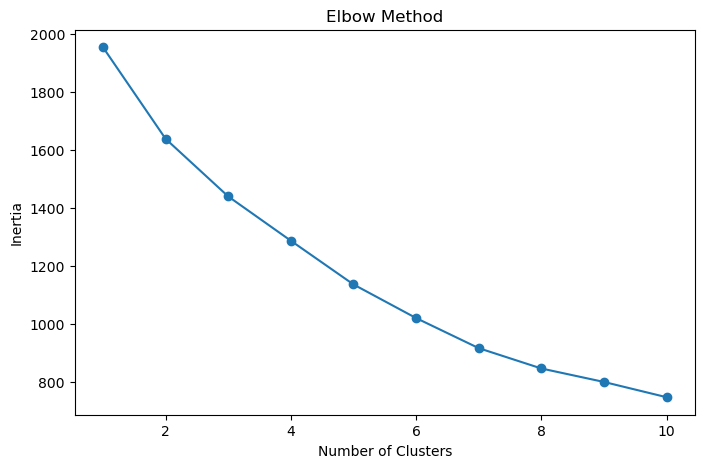

In [12]:
# =====================================================
# ELBOW METHOD
# =====================================================

inertia = []

k_range = range(1, 11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    inertia,
    marker='o'
)

plt.title(
    'Elbow Method'
)

plt.xlabel(
    'Number of Clusters'
)

plt.ylabel(
    'Inertia'
)

plt.show()

## K-Means Clustering

Based on the Elbow Method, four clusters were selected to segment countries according to their economic and agricultural characteristics.

In [13]:
# =====================================================
# K-MEANS CLUSTERING
# =====================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

country_cluster['cluster'] = kmeans.fit_predict(
    scaled_data
)

country_cluster.head()

,country_name,gdp_growth,inflation,unemployment,gdp_per_capita,food_production_index,cereal_yield,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score,cluster
0,Afghanistan,-6.765792,2.640260,13.143667,409.575581,112.683333,2200.98,58.609225,106.0,73.376667,0
1,Albania,3.708793,3.472356,11.030333,8427.195097,105.346667,5175.46,38.974625,131.4,53.910000,1
2,Algeria,2.040000,6.455000,12.508500,4797.574513,109.516667,1469.56,17.344025,151.0,67.515000,1
3,American Samoa,1.788103,4.482859,5.543000,15914.292697,105.536667,3216.08,14.537500,124.6,48.893333,1
4,Andorra,2.524565,4.482859,5.543000,43663.387384,105.536667,3216.08,39.909825,124.6,32.072000,1


In [14]:
# =====================================================
# CLUSTER DISTRIBUTION
# =====================================================

country_cluster['cluster'].value_counts()

cluster
1    113
2     69
0     32
3      3
Name: count, dtype: int64

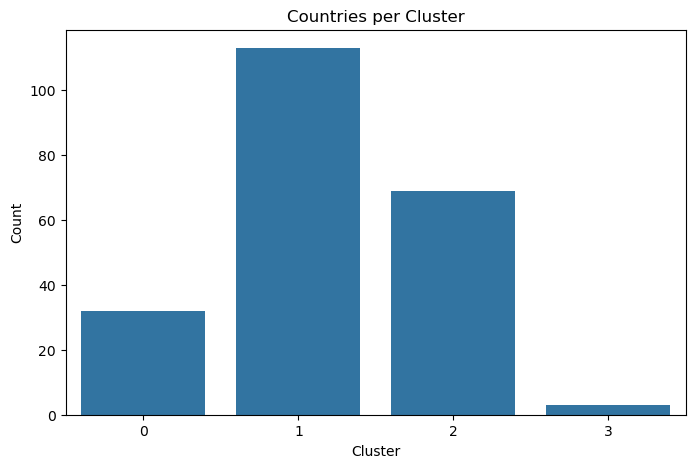

In [15]:
# =====================================================
# CLUSTER SIZE CHART
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=country_cluster,
    x='cluster'
)

plt.title('Countries per Cluster')

plt.xlabel('Cluster')

plt.ylabel('Count')

plt.show()

In [16]:
# =====================================================
# CLUSTER PROFILE
# =====================================================

cluster_profile = (
    country_cluster
    .groupby('cluster')
    [
        [
            'gdp_growth',
            'inflation',
            'unemployment',
            'gdp_per_capita',
            'food_production_index',
            'cereal_yield',
            'agricultural_land_pct',
            'dietary_energy_supply_adequacy',
            'economic_stress_score'
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile

,gdp_growth,inflation,unemployment,gdp_per_capita,food_production_index,cereal_yield,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score
cluster,,,,,,,,,
0,0.95,9.41,16.60,6071.28,102.61,1930.31,44.25,113.72,72.49
1,1.81,5.25,5.87,34587.61,103.08,4990.06,28.08,130.49,42.97
2,3.64,7.57,4.70,4811.98,119.91,2438.86,43.59,119.20,48.67
3,-4.88,203.12,10.53,2462.90,111.44,1499.33,55.37,114.18,81.20


In [17]:
# =====================================================
# SAMPLE COUNTRIES
# =====================================================

for cluster in sorted(
    country_cluster['cluster'].unique()
):
    
    print(f"\nCLUSTER {cluster}")
    print("-" * 40)
    
    display(
        country_cluster[
            country_cluster['cluster'] == cluster
        ][['country_name']]
        .head(10)
    )


CLUSTER 0
----------------------------------------


,country_name
0,Afghanistan
5,Angola
8,Armenia
25,Botswana
32,Cabo Verde
45,"Congo, Rep."
54,Djibouti
63,Eswatini
69,French Polynesia
70,Gabon



CLUSTER 1
----------------------------------------


,country_name
1,Albania
2,Algeria
3,American Samoa
4,Andorra
6,Antigua and Barbuda
7,Argentina
9,Aruba
10,Australia
11,Austria
13,"Bahamas, The"



CLUSTER 2
----------------------------------------


,country_name
12,Azerbaijan
15,Bangladesh
20,Benin
23,Bolivia
27,British Virgin Islands
30,Burkina Faso
31,Burundi
33,Cambodia
34,Cameroon
37,Central African Republic



CLUSTER 3
----------------------------------------


,country_name
110,Lebanon
185,Sudan
216,Zimbabwe


### Cluster Summary

Four distinct country segments were identified using K-Means clustering.

| Cluster | Segment Name |
|----------|-------------|
| Cluster 0 | Economically Vulnerable Countries |
| Cluster 1 | Economically Stable High-Income Countries |
| Cluster 2 | Emerging Growth Economies |
| Cluster 3 | Economic Crisis Economies |

The clustering results demonstrate that countries can be segmented into meaningful groups based on economic growth, labor market conditions, income levels, food security, and overall economic stress characteristics.

### Key Findings

The clustering analysis identified four distinct groups of countries based on their economic and agricultural characteristics.

#### Cluster 0 – Economically Vulnerable Countries
Countries characterized by high unemployment, low economic growth, and moderate food security conditions.

#### Cluster 1 – Economically Stable High-Income Countries
Countries with high income levels, low unemployment, strong food security, and relatively low economic stress.

#### Cluster 2 – Emerging Growth Economies
Countries exhibiting strong economic growth, low unemployment, and favorable agricultural performance.

#### Cluster 3 – Economic Crisis Economies
A small group of countries experiencing severe economic instability characterized by negative growth, extremely high inflation, and low income levels. Representative countries include Lebanon, Sudan, and Zimbabwe.

#### Overall Conclusion

The clustering results demonstrate that countries can be segmented into meaningful economic profiles. Labor market conditions, economic growth, income levels, and food security indicators play important roles in differentiating country groups and explaining economic vulnerability.